In [13]:
#IMPORTS

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sys
from pathlib import Path
from types import SimpleNamespace

In [34]:
#paths

ROOT="/export/home/rstanciu/"
repo_path= ROOT + "FM_thesis_Razvan/FM_thesis/Mammo-FM/src/codebase"


#data

data_ROOT= ROOT + "ZGT_Mammo-FM_format"
test_ZGT_csv="detection_final_test.csv"
images_folder="images_png"


#model checkpoints


model_pretrained_path=ROOT + "FM_thesis_Razvan/FM_thesis/Mammo-FM/Mammo-FM_BatmanlabTrained_CLIP.tar"

fold=1

model_ckpt_fold= ROOT + f"FM_thesis_Razvan/Mammo-FM/Mammo-FM_runs/fold{fold}/checkpoints/custom/Concept-Detector/breast_clip_det_b5/lr_5e-05_epochs_40_concepts_Mass_alpha_0.25_gamma_2.0_score_th_0.1_data_frac_1.0_freeze_backbone_y/breast_clip_det_b5_seed_10_fold_{fold}_best_auroc.pth"


In [15]:
#load state_dict and model

sys.path.append(str(repo_path))

from Detectors.retinanet.detector_model import RetinaNet_efficientnet
from Datasets.dataset_utils import get_dataloader_concept_detector


In [16]:
num_classes = 1  # change if your training used more classes
model_type = "breast_clip_det_b5"  

model = RetinaNet_efficientnet(
    num_classes=num_classes,
    model_type=model_type,
    clip_chk_pt=model_pretrained_path,
    freeze_backbone="n"
)

efficientnet-b5
GlobalParams(batch_norm_momentum=0.99, batch_norm_epsilon=0.001, dropout_rate=0.4, num_classes=1, width_coefficient=1.6, depth_coefficient=2.2, depth_divisor=8, min_depth=None, drop_connect_rate=0.2, image_size=456)
clip weights are loaded
Freezing the backbone of the image encode: n
Loaded pretrained weights for efficientnet-b5


In [35]:
checkpoint = torch.load(
    model_ckpt_fold,
    map_location="cpu",
    weights_only=False
)

state_dict = checkpoint["state_dict"]


state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict, strict=True)

<All keys matched successfully>

In [36]:
checkpoint["best_MAP"]

0.5046085764878094

In [37]:
args = SimpleNamespace()

args.dataset = "custom"
args.model_type = "concept-detector"

test_df=pd.read_csv(f"{data_ROOT}/{test_ZGT_csv}")

args.valid_folds = test_df

args.batch_size = 1
args.num_workers = 0

args.resize = 512
args.alpha = 1.0
args.sigma = 50

args.concepts = ["Mass"]

args.mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
args.std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

args.data_dir = Path(data_ROOT)
args.img_dir = Path(images_folder)


test_loader, test_dataset = get_dataloader_concept_detector(
    args,
    train=False
)

generating custom dataset loading


In [38]:
batch = next(iter(test_loader))

print(batch.keys())
print(batch["image"].shape)
print(batch["res_bbox_tensor"].shape)
print(batch["image_path"])

dict_keys(['image', 'res_bbox_tensor', 'image_path'])
torch.Size([1, 3, 512, 512])
torch.Size([1, 1, 5])
['/export/home/rstanciu/ZGT_Mammo-FM_format/images_png/1/1_L_CC.png']


/export/home/rstanciu/FM_thesis_Razvan/FM_thesis/Mammo-FM/src/codebase/Datasets/dataset_concepts.py:433: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor((image - self.mean) / self.std, dtype=torch.float32)


In [39]:
test_df.shape

(34, 18)

In [8]:
# Debug: Check raw data from dataset before any processing
raw_idx = 0
study_id, image_id = list(test_dataset.image_dict.keys())[raw_idx]

boxes_original = test_dataset.image_dict[(study_id, image_id)]["boxes"]
image_path = str(test_dataset.dir_path / test_dataset.image_dict[(study_id, image_id)]["image_path"])

# Load the raw image to check original shape
import cv2
raw_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print(f"Original image shape: {raw_image.shape}")
print(f"Original boxes (before any augmentation):")
for i, box in enumerate(boxes_original):
    print(f"  Box {i}: x1={box[0]:.1f}, y1={box[1]:.1f}, x2={box[2]:.1f}, y2={box[3]:.1f}, label={box[4]}")


Original image shape: (2921, 1283)
Original boxes (before any augmentation):
  Box 0: x1=360.0, y1=2123.0, x2=579.0, y2=2237.0, label=0


In [9]:
# Debug: Check box transformation through imgaug
from imgaug.augmentables.bbs import BoundingBox, BoundingBoxesOnImage

# Get the test augmentation transform
raw_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
raw_image_rgb = cv2.cvtColor(raw_image, cv2.COLOR_GRAY2RGB)

print(f"Before transform:")
print(f"  Image shape: {raw_image_rgb.shape}")

# Create bounding boxes in original coordinates
bb_original = []
for bb in boxes_original:
    bb_original.append(BoundingBox(x1=bb[0], y1=bb[1], x2=bb[2], y2=bb[3]))

bbs_on_image_original = BoundingBoxesOnImage(bb_original, shape=raw_image_rgb.shape)

# Apply the test transform (which includes resize and crop)
from Datasets.dataset_utils import get_transforms

transform, train_affine_trans, test_affine_trans = get_transforms(args)

transformed_image, boxes_transformed = test_affine_trans(
    image=raw_image_rgb,
    bounding_boxes=[bbs_on_image_original]
)

print(f"\nAfter transform:")
print(f"  Image shape: {transformed_image.shape}")
print(f"  Transformed boxes:")
for i, bb in enumerate(boxes_transformed[0]):
    print(f"    Box {i}: x1={bb.x1:.1f}, y1={bb.y1:.1f}, x2={bb.x2:.1f}, y2={bb.y2:.1f}")

# Check if boxes were clipped by the crop
print(f"\nBox validity check:")
for i, bb in enumerate(boxes_transformed[0]):
    outside_bounds = (bb.x1 < 0 or bb.y1 < 0 or bb.x2 > args.resize or bb.y2 > args.resize)
    print(f"  Box {i}: outside_bounds={outside_bounds}")


Before transform:
  Image shape: (2921, 1283, 3)

After transform:
  Image shape: (512, 512, 3)
  Transformed boxes:
    Box 0: x1=143.7, y1=372.1, x2=231.1, y2=392.1

Box validity check:
  Box 0: outside_bounds=False


In [10]:
# Compare expected transformed boxes with actual batch boxes
print("Batch data from dataloader:")
batch = next(iter(test_loader))
batch_boxes = batch["res_bbox_tensor"][0]  # First image in batch
print(f"  Batch boxes shape: {batch_boxes.shape}")
print(f"  Batch boxes:")
for i, box in enumerate(batch_boxes):
    if (box != -1).all():  # Skip padding
        print(f"    Box {i}: x1={box[0]:.1f}, y1={box[1]:.1f}, x2={box[2]:.1f}, y2={box[3]:.1f}, label={box[4]:.1f}")

print(f"\nExpected (from manual transform):")
for i, bb in enumerate(boxes_transformed[0]):
    print(f"  Box {i}: x1={bb.x1:.1f}, y1={bb.y1:.1f}, x2={bb.x2:.1f}, y2={bb.y2:.1f}")

print(f"\nMatch check: Do batch boxes match manually transformed boxes?")
for i, bb in enumerate(boxes_transformed[0]):
    batch_box = batch_boxes[i]
    match = (abs(batch_box[0] - bb.x1) < 0.1 and 
             abs(batch_box[1] - bb.y1) < 0.1 and 
             abs(batch_box[2] - bb.x2) < 0.1 and 
             abs(batch_box[3] - bb.y2) < 0.1)
    print(f"  Box {i}: {'✓ MATCH' if match else '✗ MISMATCH'}")


Batch data from dataloader:
  Batch boxes shape: torch.Size([1, 5])
  Batch boxes:
    Box 0: x1=143.7, y1=372.1, x2=231.1, y2=392.1, label=0.0

Expected (from manual transform):
  Box 0: x1=143.7, y1=372.1, x2=231.1, y2=392.1

Match check: Do batch boxes match manually transformed boxes?
  Box 0: ✓ MATCH


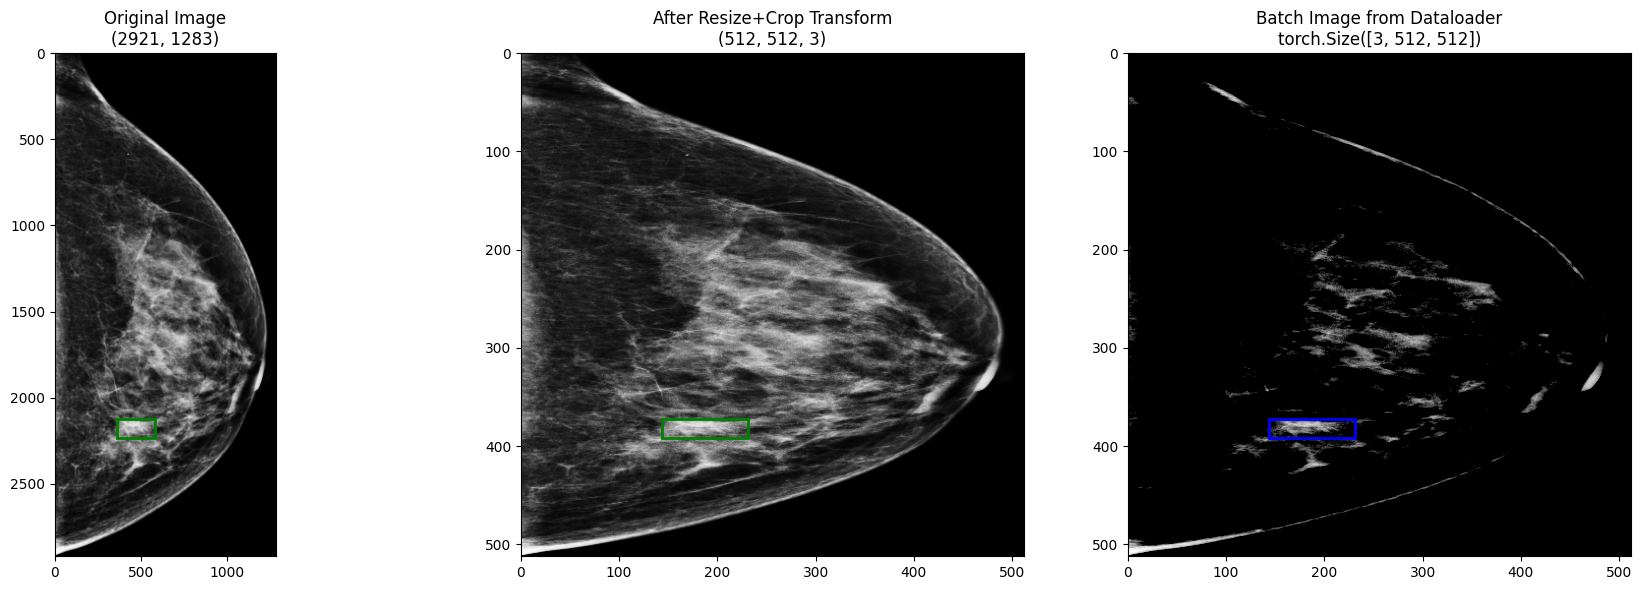

✓ Green boxes: manually transformed
✓ Blue boxes: from batch dataloader

If boxes don't align, there may be an issue with the imgaug transformation


In [12]:
# Visual inspection: Plot original image with original boxes vs resized image with transformed boxes
from matplotlib import patches


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Original image with original boxes
raw_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
axes[0].imshow(raw_image, cmap='gray')
axes[0].set_title(f'Original Image\n{raw_image.shape}')
for bb in boxes_original:
    rect = patches.Rectangle((bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1], 
                             linewidth=2, edgecolor='green', facecolor='none')
    axes[0].add_patch(rect)
axes[0].set_xlim(0, raw_image.shape[1])
axes[0].set_ylim(raw_image.shape[0], 0)

# Plot 2: Manually transformed image with transformed boxes
axes[1].imshow(transformed_image, cmap='gray')
axes[1].set_title(f'After Resize+Crop Transform\n{transformed_image.shape}')
for bb in boxes_transformed[0]:
    rect = patches.Rectangle((bb.x1, bb.y1), bb.x2-bb.x1, bb.y2-bb.y1, 
                             linewidth=2, edgecolor='green', facecolor='none')
    axes[1].add_patch(rect)
axes[1].set_xlim(0, args.resize)
axes[1].set_ylim(args.resize, 0)

# Plot 3: Batch image with batch boxes
batch = next(iter(test_loader))
batch_image = batch["image"][0]
batch_boxes = batch["res_bbox_tensor"][0]

# Unnormalize the image for visualization
axes[2].imshow(batch_image[0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Batch Image from Dataloader\n{batch_image.shape}')
for i, box in enumerate(batch_boxes):
    if (box != -1).all():  # Skip padding
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                linewidth=2, edgecolor='blue', facecolor='none')
        axes[2].add_patch(rect)
axes[2].set_xlim(0, args.resize)
axes[2].set_ylim(args.resize, 0)

plt.tight_layout()
plt.show()

print("✓ Green boxes: manually transformed")
print("✓ Blue boxes: from batch dataloader")
print("\nIf boxes don't align, there may be an issue with the imgaug transformation")


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)

        scores, labels, boxes = model(images)

        print(scores)
        print(labels)
        print(boxes)
        break

tensor([0.2353, 0.1765, 0.1488, 0.1253, 0.1132, 0.0823, 0.0741, 0.0716, 0.0609,
        0.0583, 0.0579, 0.0567, 0.0540], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([[  0.0000,  36.4904,  32.9957,  65.5893],
        [ 82.8346, 325.4459, 137.1702, 356.3291],
        [  0.0000, 361.6776,  23.9752, 396.8515],
        [  0.0000, 483.4160,  36.5548, 512.0000],
        [  0.0000,  26.7201,  49.0455,  64.7741],
        [165.6982, 189.3647, 210.7816, 217.8796],
        [185.3701, 192.9490, 221.3996, 214.1152],
        [277.3154, 281.7889, 314.6750, 309.1307],
        [140.2680, 366.1089, 198.8036, 396.5610],
        [146.9616, 178.6900, 211.6244, 219.0895],
        [  0.0000, 480.8647,  22.5274, 505.1051],
        [  0.0000,  41.8892,  23.0989,  72.1473],
        [  0.0000,  21.2534,  26.0470,  56.5496]], device='cuda:0')


In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def unnormalize_image(img, mean, std):
    """
    img: torch.Tensor [3, H, W]
    mean/std: tensor [3,1,1] or list of 3 values
    """
    img = img.detach().cpu()

    if not torch.is_tensor(mean):
        mean = torch.tensor(mean).view(3, 1, 1)
    if not torch.is_tensor(std):
        std = torch.tensor(std).view(3, 1, 1)

    mean = mean.cpu()
    std = std.cpu()

    img = img * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()

    return img


def visualize_gt_and_predictions(
    image,
    gt_boxes=None,
    pred_boxes=None,
    pred_scores=None,
    pred_labels=None,
    mean=None,
    std=None,
    score_thresh=0.05,
    class_names=None,
    figsize=(8, 8),
):
    """
    image: torch.Tensor [3, H, W]
    gt_boxes: torch.Tensor [N, 5] where columns are x1,y1,x2,y2,label
              or [N, 4]
    pred_boxes: torch.Tensor [M, 4]
    pred_scores: torch.Tensor [M]
    pred_labels: torch.Tensor [M]
    """

    if mean is not None and std is not None:
        img = unnormalize_image(image, mean, std)
    else:
        img = image.detach().cpu().permute(1, 2, 0).numpy()
        img = img.clip(0, 1)

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(img, cmap="gray")

    # Ground truth boxes: green
    if gt_boxes is not None:
        gt_boxes = gt_boxes.detach().cpu()

        # remove padded -1 boxes
        gt_boxes = gt_boxes[gt_boxes[:, 0] >= 0]

        for box in gt_boxes:
            x1, y1, x2, y2 = box[:4].tolist()
            label = int(box[4].item()) if box.shape[0] >= 5 else None

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)

            text = "GT"
            if label is not None and class_names is not None:
                text += f": {class_names[label]}"

            ax.text(
                x1,
                y1,
                text,
                color="lime",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5),
            )

    # Predicted boxes: red
    if pred_boxes is not None and pred_scores is not None:
        pred_boxes = pred_boxes.detach().cpu()
        pred_scores = pred_scores.detach().cpu()

        if pred_labels is not None:
            pred_labels = pred_labels.detach().cpu()

        keep = pred_scores >= score_thresh

        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]

        if pred_labels is not None:
            pred_labels = pred_labels[keep]

        for i, box in enumerate(pred_boxes):
            x1, y1, x2, y2 = box.tolist()
            score = float(pred_scores[i])

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

            text = f"Pred {score:.2f}"

            if pred_labels is not None and class_names is not None:
                label = int(pred_labels[i].item())
                text += f": {class_names[label]}"

            ax.text(
                x1,
                y2,
                text,
                color="red",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5),
            )

    ax.axis("off")
    plt.show()

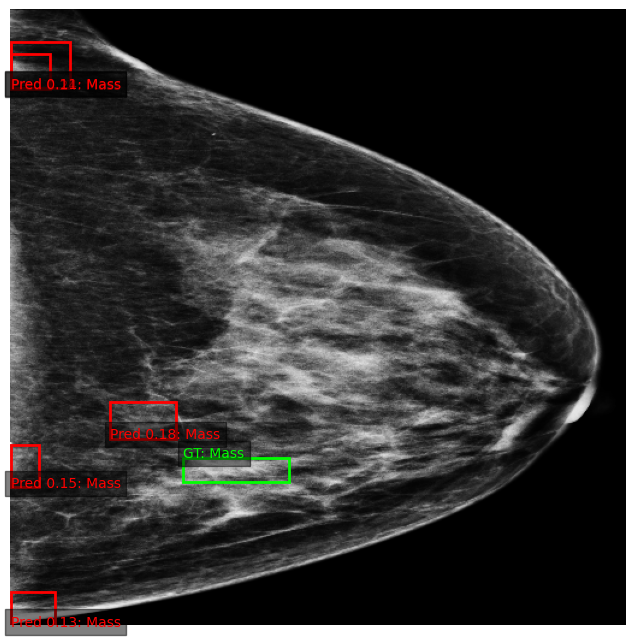

In [42]:
model.eval()

batch = next(iter(test_loader))

images = batch["image"].to(device)
gt_boxes = batch["res_bbox_tensor"]

with torch.no_grad():
    scores, labels, boxes = model(images)

visualize_gt_and_predictions(
    image=batch["image"][0],
    gt_boxes=gt_boxes[0],
    pred_boxes=boxes,
    pred_scores=scores,
    pred_labels=labels,
    mean=args.mean,
    std=args.std,
    score_thresh=0.1,
    class_names=args.concepts,
)